In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore

**Loading in the Data**

In [ ]:
# loading the data into a dataframe
water_df = pd.read_csv("/content/water_pivoted.csv")
water_df.head()

,Sample Site,Latitude (Degrees),Longitude (Degrees),Sample Date,Site Key,(Aminomethyl)phosphonic acid,"2,4-D","2,4-DB","2,4-DP","2,4-Dichlorophenol",...,Vanadium (V)(Total),Vinclozolin,Water Temperature (Field),Zinc (Zn)(Extractable),Zinc (Zn)(Total),alpha-BHC,alpha-Endosulfan,gamma-BHC,"p,p-Methoxychlor",pH
0,Bearspaw Reservoir Centre,51.117405,-114.292106,1993 Aug 04 12:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.7,NaN,NaN,NaN,NaN,NaN,NaN,8.2
1,Bearspaw Reservoir Centre,51.117405,-114.292106,1993 Aug 11 12:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.6,NaN,NaN,NaN,NaN,NaN,NaN,8.1
2,Bearspaw Reservoir Centre,51.117405,-114.292106,1993 Aug 18 12:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.6,NaN,NaN,NaN,NaN,NaN,NaN,8.1
3,Bearspaw Reservoir Centre,51.117405,-114.292106,1993 Aug 26 12:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.2,NaN,NaN,NaN,NaN,NaN,NaN,8.2
4,Bearspaw Reservoir Centre,51.117405,-114.292106,1993 Jul 07 12:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.5,NaN,NaN,NaN,NaN,NaN,NaN,8.2


In [ ]:
# dropping any rows that are missing the target variable of total coliforms
water_df = water_df.dropna(subset = ['Total Coliforms'])

**Creating a Bar Graph Showing Contaminated vs Safe Counts**

In [ ]:
# creates a binary column where contaminated water is a 1 and safe water is a 0
# total coliforms > 235 are considered contaminated, total coliforms < 235 are considered safe
water_df["contaminated"] = (water_df["Total Coliforms"] > 235).astype(int)
water_df.head()

,Sample Site,Latitude (Degrees),Longitude (Degrees),Sample Date,Site Key,(Aminomethyl)phosphonic acid,"2,4-D","2,4-DB","2,4-DP","2,4-Dichlorophenol",...,Vinclozolin,Water Temperature (Field),Zinc (Zn)(Extractable),Zinc (Zn)(Total),alpha-BHC,alpha-Endosulfan,gamma-BHC,"p,p-Methoxychlor",pH,contaminated
101,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Aug 20 11:45:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,16.75,NaN,NaN,NaN,NaN,NaN,NaN,8.4,0
102,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Jul 27 12:00:00 PM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,16.28,NaN,NaN,NaN,NaN,NaN,NaN,8.4,0
103,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Jun 24 11:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,14.06,NaN,NaN,NaN,NaN,NaN,NaN,8.3,0
104,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 May 27 11:36:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,12.10,NaN,NaN,NaN,NaN,NaN,NaN,8.2,0
105,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Oct 14 11:26:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,NaN,8.12,NaN,NaN,NaN,NaN,NaN,NaN,8.2,0


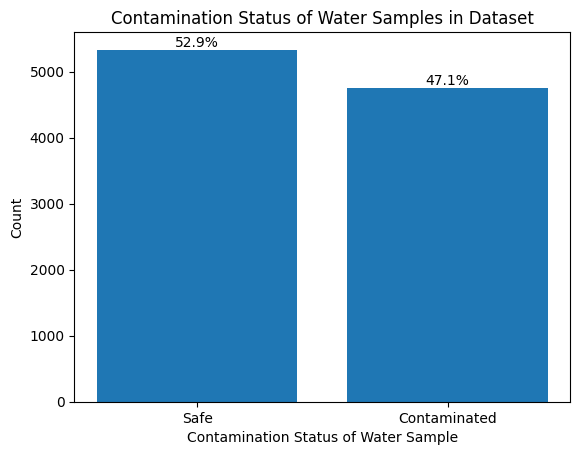

In [ ]:
# creates a bar showing number of contaminated versus safe samples
contaminated_counts = water_df.contaminated.value_counts().reset_index()
plt.bar(contaminated_counts["contaminated"], contaminated_counts["count"])
plt.title("Contamination Status of Water Samples in Dataset")
plt.xlabel("Contamination Status of Water Sample")
plt.ylabel("Count")
plt.xticks([0, 1], ["Safe", "Contaminated"])

# gets and displays percentages for each bar
total_count = contaminated_counts['count'].sum()
for index, row in contaminated_counts.iterrows():
    percentage = (row['count'] / total_count) * 100
    plt.text(row['contaminated'], row['count'] + 50, f'{percentage:.1f}%', ha='center')

plt.show()

In [ ]:
# prints the class counts for "contaminated"
contaminated_counts

,contaminated,count
0,0,5333
1,1,4751


**Removing Outliers in Total Coliforms**

For the purpose of creating more readable visualizations we will remove outliers for total coliforms.

In [ ]:
# examining distribution of total coliforms in dataset
water_df['Total Coliforms'].describe()

,Total Coliforms
count,10084.000000
mean,1183.160660
std,7091.989128
min,1.000000
25%,48.325000
50%,200.500000
75%,803.250000
max,242000.000000


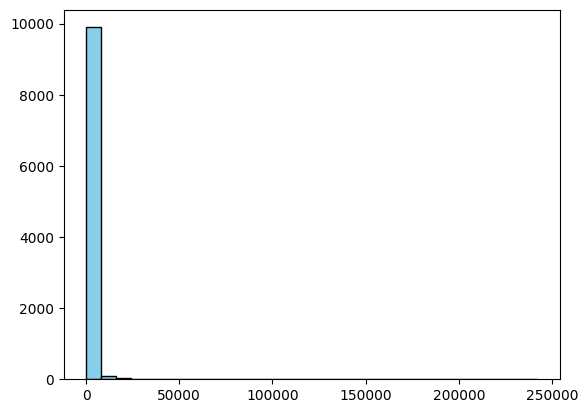

In [ ]:
# creates a histogram of total coliforms in dataset
plt.hist(water_df['Total Coliforms'], bins=30, color='skyblue', edgecolor='black')
plt.show()

In [ ]:
# from the above histogram it appears that we have extreme outliers for total coliforms
# total coliforms with an absolute zscore of greater than 3 will be removed from the dataset
water_df['z_score'] = np.abs(zscore(water_df['Total Coliforms']))
threshold = 3
water_no_outliers = water_df[water_df["z_score"] <= 3].copy()
water_no_outliers.head()

,Sample Site,Latitude (Degrees),Longitude (Degrees),Sample Date,Site Key,(Aminomethyl)phosphonic acid,"2,4-D","2,4-DB","2,4-DP","2,4-Dichlorophenol",...,Water Temperature (Field),Zinc (Zn)(Extractable),Zinc (Zn)(Total),alpha-BHC,alpha-Endosulfan,gamma-BHC,"p,p-Methoxychlor",pH,contaminated,z_score
101,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Aug 20 11:45:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,16.75,NaN,NaN,NaN,NaN,NaN,NaN,8.4,0,0.151849
102,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Jul 27 12:00:00 PM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,16.28,NaN,NaN,NaN,NaN,NaN,NaN,8.4,0,0.135478
103,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Jun 24 11:00:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,14.06,NaN,NaN,NaN,NaN,NaN,NaN,8.3,0,0.160888
104,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 May 27 11:36:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,12.10,NaN,NaN,NaN,NaN,NaN,NaN,8.2,0,0.160832
105,Bearspaw Reservoir Centre,51.117405,-114.292106,2015 Oct 14 11:26:00 AM,SUR_BP-C,NaN,NaN,NaN,NaN,NaN,...,8.12,NaN,NaN,NaN,NaN,NaN,NaN,8.2,0,0.159732


In [ ]:
# checks how many outliers were removed
num_removed = water_df.shape[0] - water_no_outliers.shape[0]
num_removed

71

In [ ]:
# reexamines distribution of total coliforms after removing outliers
water_no_outliers['Total Coliforms'].describe()

,Total Coliforms
count,10013.000000
mean,769.797473
std,1670.144842
min,1.000000
25%,48.000000
50%,198.900000
75%,770.100000
max,22300.000000


In [ ]:
water_no_outliers.to_csv("water_no_outliers.csv")

**Creating Visualizations of Total Coliforms over Time**

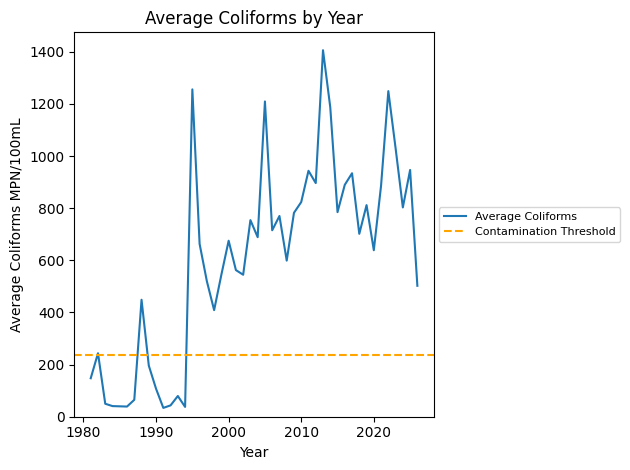

In [ ]:
# creates a line graph of average coliforms by year
# converts sample date to datetime
water_no_outliers['Sample Date'] = pd.to_datetime(water_no_outliers['Sample Date'])
# gets the year of the sample from the sample date
water_no_outliers['Year'] = water_no_outliers['Sample Date'].dt.year
# calculates the average of total coliforms for each year
yearly_coliforms = water_no_outliers.groupby("Year")['Total Coliforms'].mean().reset_index()
yearly_coliforms.rename(columns={'Total Coliforms': 'Average Coliforms'}, inplace=True)
# creates the plot
yearly_coliforms.plot(x = "Year", y = "Average Coliforms")
# adds a horizontal line representing the contamination threshold
plt.axhline(y=235, color='orange', linestyle='--', label='Contamination Threshold')
plt.title("Average Coliforms by Year")
plt.ylabel("Average Coliforms MPN/100mL")
plt.ylim(bottom=0)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8) # moves the legend to the right side of the plot and sets fontsize
plt.tight_layout() # adjust layout to prevent legend from being cut off
plt.savefig("avg_coliforms_by_year.png")
plt.show()

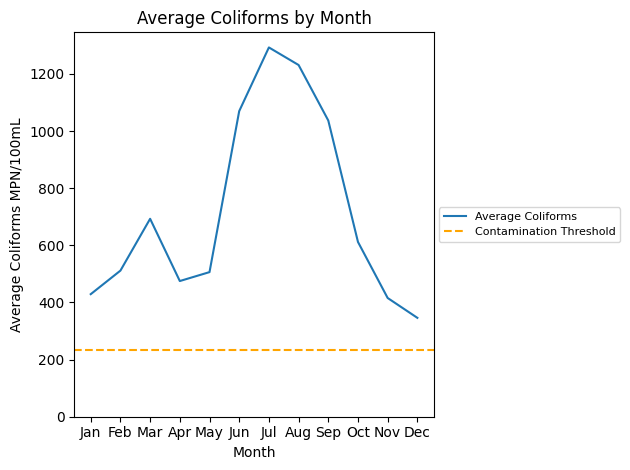

In [ ]:
import calendar
# gets the month of the sample from the sample date
water_no_outliers['Month'] = water_no_outliers['Sample Date'].dt.month
# gets the month of the sample from the sample date
monthly_coliforms = water_no_outliers.groupby("Month")['Total Coliforms'].mean().reset_index()
# calculates the average of total coliforms for each month
monthly_coliforms.rename(columns={'Total Coliforms': 'Average Coliforms'}, inplace=True);
# creates the plot
monthly_coliforms.plot(x = "Month", y = "Average Coliforms")
plt.title("Average Coliforms by Month")
plt.ylabel("Average Coliforms MPN/100mL")
# adds a horizontal line representing the contamination threshold
plt.axhline(y=235, color='orange', linestyle='--', label='Contamination Threshold')
month_names = [calendar.month_abbr[i] for i in monthly_coliforms['Month']]
plt.xticks(monthly_coliforms['Month'], month_names)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8) # moves the legend to the right side of the plot and sets fontsize
plt.tight_layout() # adjust layout to prevent legend from being cut off
plt.ylim(bottom=0)
plt.savefig("avg_coliforms_by_month.png")
plt.show()

In [ ]:
# prints a dataframe of average coliforms by month
monthly_coliforms

,Month,Average Coliforms
0,1,428.982484
1,2,511.428836
2,3,692.798489
3,4,474.940909
4,5,506.151984
5,6,1069.608658
6,7,1292.558683
7,8,1231.064519
8,9,1036.779767
9,10,611.730195


**Creating Visualizations for Distribution of Total Coliforms by Site**

In [ ]:
# checks number of unique sites
water_no_outliers["Sample Site"].nunique()

39

There are 39 unique sample sites in the data. This is too many to comfortably visualize with a box plot for each site. We only visualize the distribution of total coliforms for the sites with the most samples.

In [ ]:
# checks the number of samples for each site
site_counts = water_no_outliers["Sample Site"].value_counts().reset_index()
site_counts

,Sample Site,count
0,Elbow River Twin Bridges,932
1,Elbow River Sarcee Bridge,872
2,Elbow River Sandy Beach,641
3,Bow River Highway 22 Bridge,568
4,Elbow River Highway 22 Bridge,490
5,Elbow River Weaselhead Foot Bridge,483
6,Nose Creek Mouth,378
7,Fish Creek 37th St,365
8,Nose Creek 15th St,346
9,Bow River Cushing Bridge,322


In [ ]:
# filters for sites with 300 or more samples
site_counts_filtered = site_counts[site_counts["count"] >= 300]
site_counts_filtered

,Sample Site,count
0,Elbow River Twin Bridges,932
1,Elbow River Sarcee Bridge,872
2,Elbow River Sandy Beach,641
3,Bow River Highway 22 Bridge,568
4,Elbow River Highway 22 Bridge,490
5,Elbow River Weaselhead Foot Bridge,483
6,Nose Creek Mouth,378
7,Fish Creek 37th St,365
8,Nose Creek 15th St,346
9,Bow River Cushing Bridge,322


In [ ]:
# gets a list of sites with over 300 samples
# the distribution of total coliforms for these sites will be visualized
sites_to_plot = site_counts_filtered["Sample Site"].to_list()
sites_to_plot

['Elbow River Twin Bridges',
 'Elbow River Sarcee Bridge',
 'Elbow River Sandy Beach',
 'Bow River Highway 22 Bridge',
 'Elbow River Highway 22 Bridge',
 'Elbow River Weaselhead Foot Bridge',
 'Nose Creek Mouth',
 'Fish Creek 37th St',
 'Nose Creek 15th St',
 'Bow River Cushing Bridge',
 'Elbow River Above Bragg Creek',
 'West Nose Creek Mountain View Rd']

In [ ]:
# filters the dataframe for only sites with more than 300 samples
water_sites_filtered = water_no_outliers[water_no_outliers['Sample Site'].isin(sites_to_plot)]
water_sites_filtered["Sample Site"].value_counts()

,count
Sample Site,
Elbow River Twin Bridges,932
Elbow River Sarcee Bridge,872
Elbow River Sandy Beach,641
Bow River Highway 22 Bridge,568
Elbow River Highway 22 Bridge,490
Elbow River Weaselhead Foot Bridge,483
Nose Creek Mouth,378
Fish Creek 37th St,365
Nose Creek 15th St,346


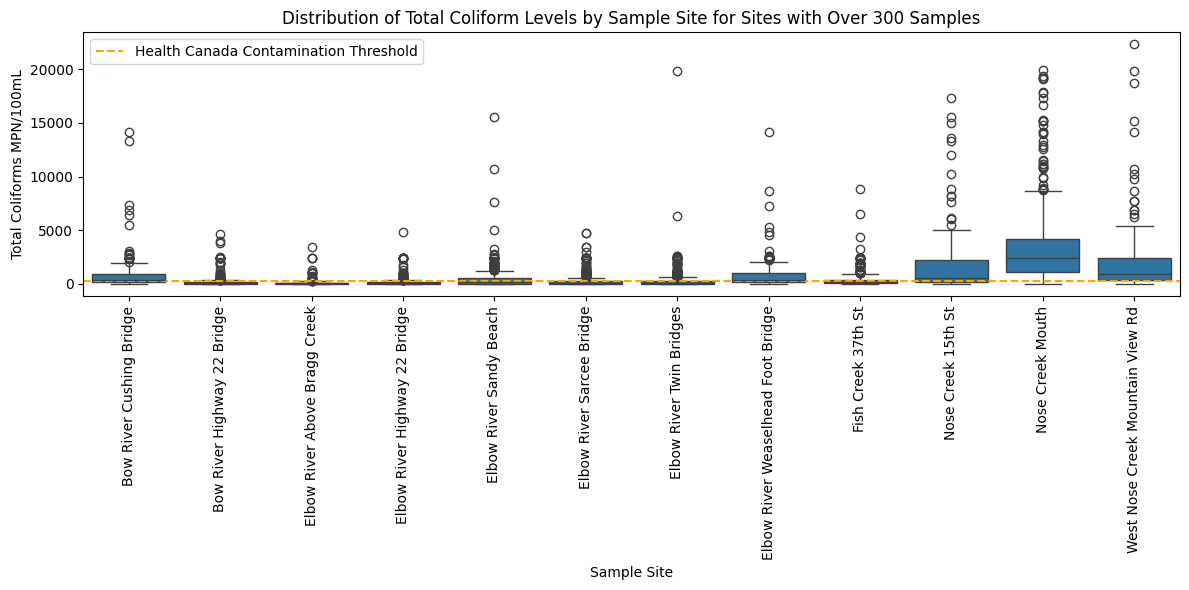

In [ ]:
# creates side by side boxplots for the distribution in total coliforms by site
plt.figure(figsize=(12, 6)) # Make the chart area bigger
sns.boxplot(x='Sample Site', y='Total Coliforms', data=water_sites_filtered)
# adds an orange line representing the health canada threshold for contamination
plt.axhline(y=235, color='orange', linestyle='--', label='Health Canada Contamination Threshold')
plt.title("Distribution of Total Coliform Levels by Sample Site for Sites with Over 300 Samples")
plt.ylabel("Total Coliforms MPN/100mL")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout() # adjust layout to prevent legend from being cut off
plt.savefig("coliforms_by_site.png")
plt.show()

**Creating a Heatmap of Correlations**

In [ ]:
water_filtered = water_no_outliers[['Total Coliforms','pH',
 'Turbidity',
 'Total Phosphorus (TP)',
 'Specific Conductance (Field)',
 'Water Temperature (Field)',
 'Total Suspended Solids (TSS)',
 'Nitrate (NO3-N)',
 'Ammonia (NH3-N)',
 'True Color',
 'Total Organic Carbon (TOC)',
 'Total Dissolved Phosphorus (TDP)',
 'NOx (Calculated)',
 'Nitrite (NO2-N)',
 'Sulphate (SO4)',
 'Total Alkalinity',
 'Chloride (Cl)',
 'Potassium (K)(Dissolved)',
 'Sodium (Na)(Dissolved)',
 'Magnesium (Mg)(Dissolved)',
 'Calcium (Ca)(Dissolved)',
 'Sodium Adsorption Ratio (SAR)(Calculated)',
 'Dissolved Oxygen (Field)',
 'Total Kjeldahl Nitrogen (TKN)',
 'Hardness',
 'Fluoride (F)']]
water_filtered.head()

,Total Coliforms,pH,Turbidity,Total Phosphorus (TP),Specific Conductance (Field),Water Temperature (Field),Total Suspended Solids (TSS),Nitrate (NO3-N),Ammonia (NH3-N),True Color,...,Chloride (Cl),Potassium (K)(Dissolved),Sodium (Na)(Dissolved),Magnesium (Mg)(Dissolved),Calcium (Ca)(Dissolved),Sodium Adsorption Ratio (SAR)(Calculated),Dissolved Oxygen (Field),Total Kjeldahl Nitrogen (TKN),Hardness,Fluoride (F)
101,106.3,8.4,2.01,0.005,278.8,16.75,NaN,0.0797,0.05,1.0,...,1.6,0.65,1.9,12.0,37.0,0.38,8.87,0.070,143.0,0.120
102,222.4,8.4,2.87,0.005,272.6,16.28,NaN,0.0754,0.05,1.0,...,1.5,0.42,1.7,12.0,36.0,0.35,8.80,0.074,140.0,0.096
103,42.2,8.3,5.18,0.007,269.5,14.06,NaN,0.1010,0.05,2.3,...,1.5,0.40,1.8,12.0,37.0,0.36,9.27,0.097,135.0,0.120
104,42.6,8.2,7.10,0.011,296.3,12.10,NaN,0.1111,0.05,1.0,...,1.7,0.51,2.0,13.0,42.0,0.38,9.36,0.103,158.0,0.110
105,50.4,8.2,2.41,0.003,299.0,8.12,NaN,0.1143,0.05,1.0,...,1.8,0.53,2.1,12.0,38.0,0.42,10.18,0.080,157.0,0.120


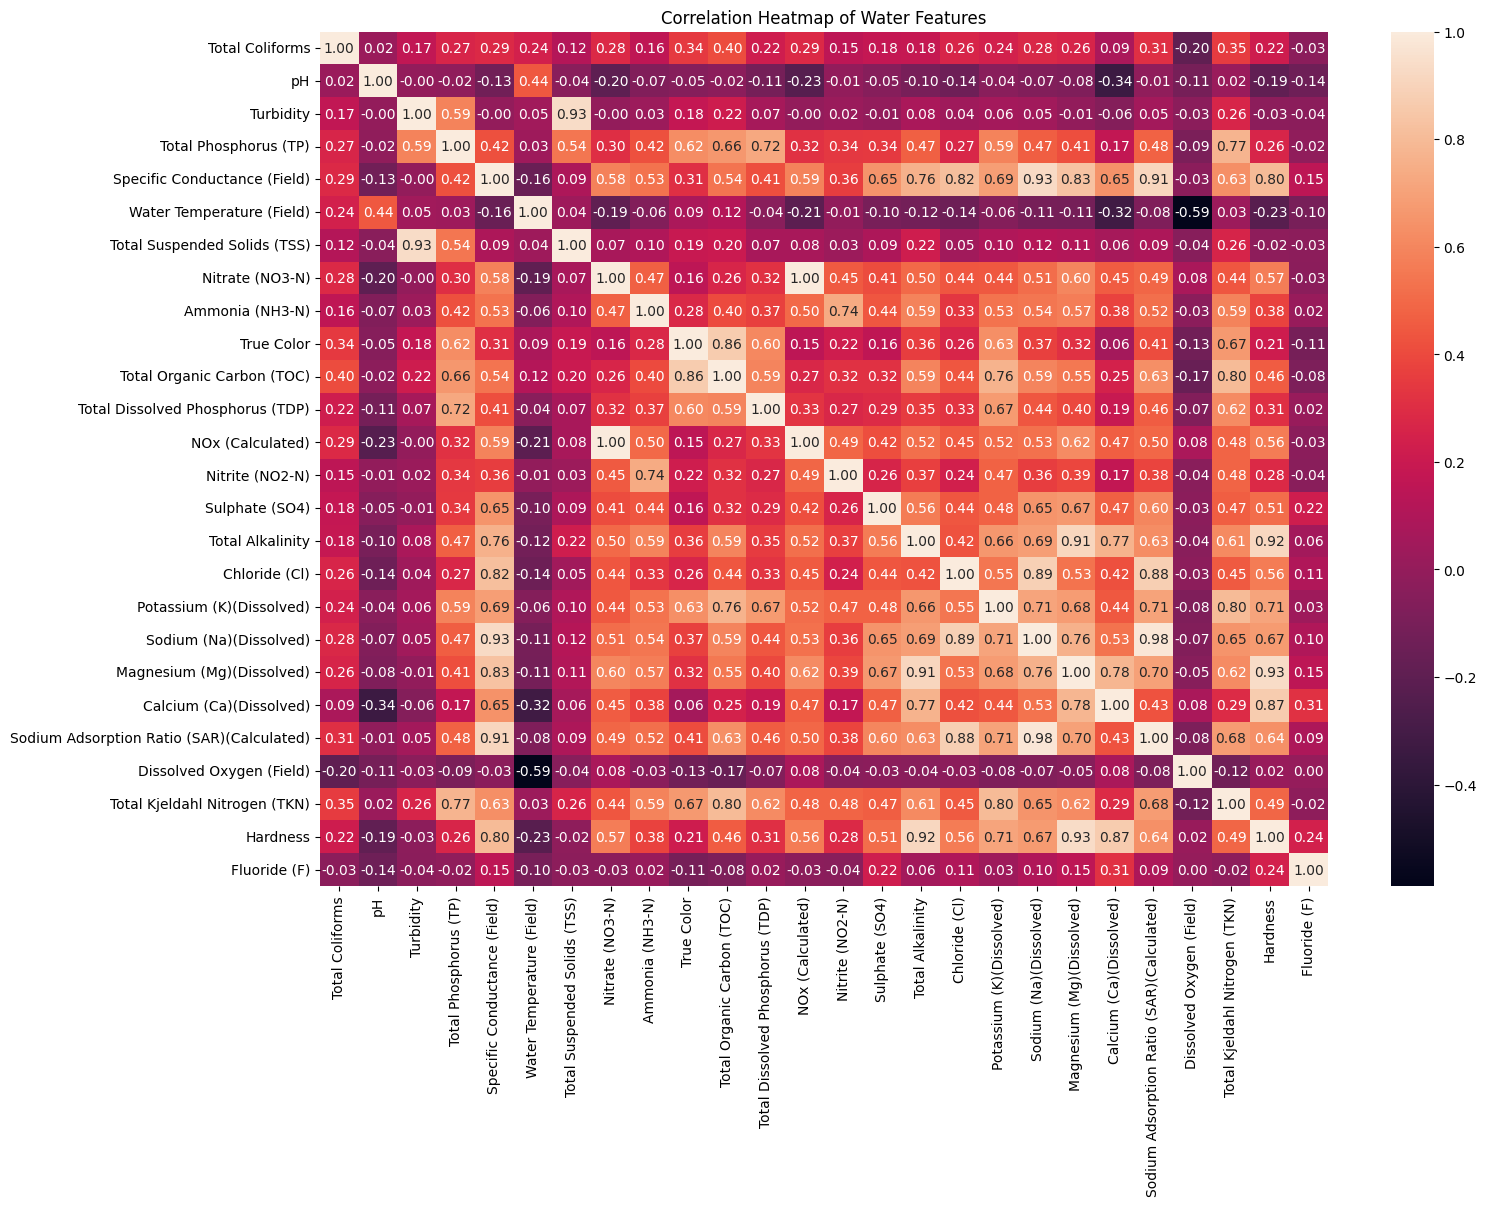

In [ ]:
plt.figure(figsize=(16, 12)) # Make the chart area bigger for readability
corr_matrix = water_filtered.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.title("Correlation Heatmap of Water Features")
plt.savefig("correlation_heatmap.png")
plt.show()